In [4]:
import numpy as np
import pandas as pd
import keras
import matplotlib.pyplot as plt
from keras import layers
import os

In [ ]:
os.chdir(r'C:\Users\PC\Documents\Proj_MPA\Recontrucao\Para\4-Scombridae&afins')

Epoch 1/1000


c:\Users\PC\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.9985
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.9460
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.8985
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.8504
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.7967
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.7382
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.6752
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.6114
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.5522
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.5051
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.4773
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.4650
Epoch 13/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.4504
Epoch 14/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.4277
Epoch 15/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.4062
Epoch 16/1000
1/1 ━

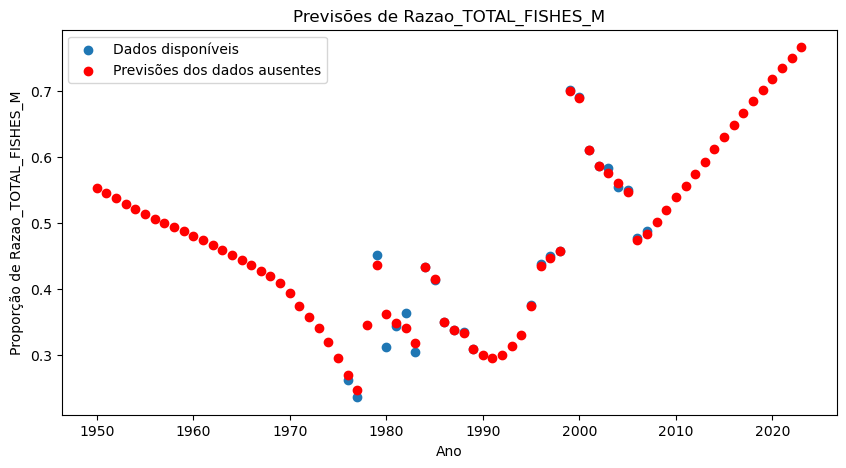

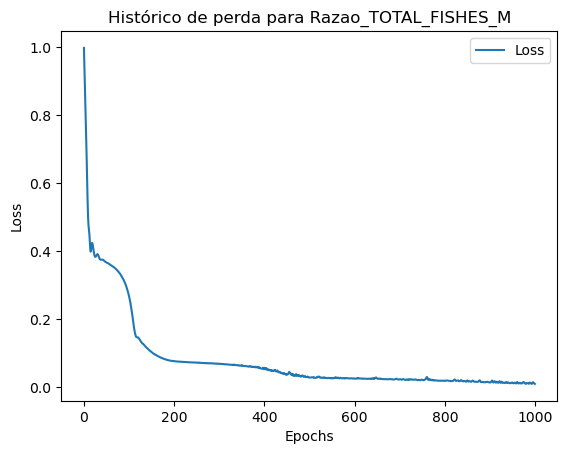

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Previsões para Razao_TOTAL_FISHES_M: [[0.55260724]
 [0.54474604]
 [0.53688484]
 [0.5290228 ]
 [0.52116233]
 [0.5133007 ]
 [0.50565505]
 [0.49938408]
 [0.4931131 ]
 [0.48684323]
 [0.4802617 ]
 [0.47327518]
 [0.46615392]
 [0.45911396]
 [0.45185778]
 [0.44395673]
 [0.4358219 ]
 [0.42746148]
 [0.41892162]
 [0.40922558]
 [0.39390418]
 [0.3743687 ]
 [0.35732841]
 [0.34038046]
 [0.31889635]
 [0.29573888]
 [0.27039313]
 [0.247319  ]
 [0.34497923]
 [0.43578583]
 [0.36146426]
 [0.34788287]
 [0.34039965]
 [0.31798953]
 [0.43293935]
 [0.4150064 ]
 [0.3501568 ]
 [0.3382372 ]
 [0.33353835]
 [0.3087723 ]
 [0.2995702 ]
 [0.29570276]
 [0.30009198]
 [0.3137233 ]
 [0.330794  ]
 [0.37343186]
 [0.43490213]
 [0.44736275]
 [0.45701048]
 [0.6987605 ]
 [0.68909806]
 [0.61028177]
 [0.5853296 ]
 [0.57532525]
 [0.560882  ]
 [0.5466274 ]
 [0.47424328]
 [0.4827708 ]
 [0.5017835 ]
 [0.51997334]
 [0.5386142 ]
 [0.5562519 ]
 [0.57358056]
 [0.59124714]
 [0.6108834 ]
 [0.6295206 ]
 

In [6]:
# Carregar o arquivo Excel
df = pd.read_excel('Extrapolacao_TOTAL_FISHES_M.xlsx')

# Listar as espécies de interesse
tipos_especies = [
   'Razao_TOTAL_FISHES_M'

]  # Adicione as espécies que você deseja

# Anos para prever
anos_para_prever = np.arange(1950, 2024)

# Iterar sobre cada espécie
for tipo in tipos_especies:
    # Selecionar as colunas necessárias e remover valores nulos
    dados = df[['Ano', tipo]].dropna()
    anos_com_dados = dados['Ano'].values
    especie_dados = dados[tipo].values

    # Normalizar os anos e os valores da espécie
    ano_mean = np.mean(anos_com_dados)
    ano_std = np.std(anos_com_dados)
    anos_com_dados_norm = (anos_com_dados - ano_mean) / ano_std
    anos_para_prever_norm = (anos_para_prever - ano_mean) / ano_std

    especie_mean = np.mean(especie_dados)
    especie_std = np.std(especie_dados)
    especie_norm = (especie_dados - especie_mean) / especie_std

    # Criar e compilar o modelo
    model = keras.Sequential([
        layers.Dense(96, activation='leaky_relu', input_shape=(1,)),
        layers.Dense(32, activation='leaky_relu'),
        layers.Dense(80, activation='leaky_relu'),
        layers.Dense(80, activation='leaky_relu'),
        layers.Dense(96, activation='leaky_relu'),
        layers.Dense(112, activation='leaky_relu'),
        layers.Dense(1, activation='linear')
    ])
    opt = keras.optimizers.Adam(learning_rate=0.001)
    model.compile(optimizer=opt, loss='mse')

    # Treinar o modelo
    history = model.fit(anos_com_dados_norm, especie_norm, epochs=1000, verbose=1)
    model.save_weights(f'W_I_{tipo}.weights.h5', overwrite=True)

    # Carregar os pesos do modelo para previsões
    model.load_weights(f'W_I_{tipo}.weights.h5')

    # Previsões para os anos ausentes
    prev_ausentes = model.predict(anos_para_prever_norm) * especie_std + especie_mean

    # Corrigir valores negativos
    prev_ausentes = np.where(prev_ausentes < 0, 0, prev_ausentes)

    # Plotar os dados e as previsões
    plt.figure(figsize=(10, 5))
    plt.scatter(anos_com_dados, especie_dados, label='Dados disponíveis')
    plt.scatter(anos_para_prever, prev_ausentes, color='red', label='Previsões dos dados ausentes')
    plt.title(f'Previsões de {tipo}')
    plt.xlabel('Ano')
    plt.ylabel(f'Proporção de {tipo}')
    plt.legend()
    plt.show()

    # Plotar o histórico de perda
    plt.figure()
    plt.plot(history.history['loss'], label='Loss')
    plt.title(f'Histórico de perda para {tipo}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    # Salvar previsões contínuas para todos os anos
    anos = np.arange(1950, 2024)
    anos_norm = (anos - ano_mean) / ano_std
    prev_continua = model.predict(anos_norm) * especie_std + especie_mean
    prev_continua = np.where(prev_continua < 0, 0, prev_continua)
    np.save(f'prev_{tipo}', prev_continua)

    # Criar DataFrame de previsões
    df_previsoes = pd.DataFrame({'Ano': anos_para_prever, tipo: prev_ausentes.flatten()})
    
  
    # Concatenar com os dados originais e remover duplicatas, priorizando os dados originais
    df_preenchido = pd.concat((dados, df_previsoes)).sort_values('Ano').drop_duplicates(subset='Ano', keep='first')


    # Salvar o DataFrame preenchido em um arquivo Excel
    df_preenchido.to_excel(f'Interpolações_{tipo}.xlsx')

    print(f'Previsões para {tipo}:', prev_ausentes)